## Project #4  


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

In [66]:
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts = all_tracts[all_tracts["STATE"] == "Wyoming"]

state_tracts.to_csv("state_tracts_wyoming.csv")

all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts = all_tracts[all_tracts["STATE"] == "Oklahoma"]

state_tracts.to_csv("state_tracts_oklahoma.csv")


In [67]:
##Install any needed pacakages with the following code, then comment the code out
import sys
!{sys.executable} -m pip install seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import sys
!{sys.executable} -m pip install geopandas

##Import
import geopandas as gpd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
#### Load in each CSV
wy_nri = pd.read_csv("state_tracts_wyoming.csv")
wy_svi = pd.read_csv("Wyoming.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

print(wy_nri)
print(nri_dictionary)
print(wy_svi)

ok_nri = pd.read_csv("state_tracts_oklahoma.csv")
ok_svi = pd.read_csv("Oklahoma.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

print(ok_nri)
print(nri_dictionary)
print(ok_svi)
#print(ne_nri)
#print(nri_dictionary)
#print(ne_svi)

     Unnamed: 0   OID_        NRI_ID    STATE STATEABBRV  STATEFIPS    COUNTY  \
0         83054  83934  T56001962700  Wyoming         WY         56    Albany   
1         83055  83935  T56001962800  Wyoming         WY         56    Albany   
2         83056  83936  T56001962900  Wyoming         WY         56    Albany   
3         83057  83937  T56001963000  Wyoming         WY         56    Albany   
4         83058  83938  T56001963101  Wyoming         WY         56    Albany   
..          ...    ...           ...      ...        ...        ...       ...   
155       83209  84089  T56043000200  Wyoming         WY         56  Washakie   
156       83210  84090  T56043000301  Wyoming         WY         56  Washakie   
157       83211  84091  T56043000302  Wyoming         WY         56  Washakie   
158       83212  84092  T56045951100  Wyoming         WY         56    Weston   
159       83213  84093  T56045951300  Wyoming         WY         56    Weston   

    COUNTYTYPE  COUNTYFIPS 

In [70]:
wy_nri['STCNTY'] = wy_nri['STCOFIPS']
ok_nri['STCNTY'] = ok_nri['STCOFIPS']

print("Join key added to both NRI dataframes.")

Join key added to both NRI dataframes.


In [71]:
complete_data_ok = pd.merge(ok_nri, ok_svi, on='STCNTY', suffixes=('', '_svi'))

# Check if it worked
print(f"New dataset shape: {complete_data.shape}")
complete_data.head()

New dataset shape: (1986, 643)


,Unnamed: 0,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,exposure_drought,exposure_tornado,exposure_winter_storm,exposure_hail,hazard_exposure,resilience_score,new_risk_raw,new_risk_score,new_risk_rank,new_risk_rating
0,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,0.0,1382.232841,72513.438373,6781.730756,81562.835585,0.875984,92059.021911,0.228398,893,Very Low
1,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,0.0,1382.232841,72513.438373,6781.730756,81562.835585,0.714584,112565.026418,0.281502,756,Very Low
2,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,0.0,1382.232841,72513.438373,6781.730756,81562.835585,0.591184,135670.299457,0.341337,654,Very Low
3,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,0.0,1382.232841,72513.438373,6781.730756,81562.835585,0.675009,119068.240030,0.298343,723,Very Low
4,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,0.0,1382.232841,72513.438373,6781.730756,81562.835585,0.874409,92222.965214,0.228822,892,Very Low


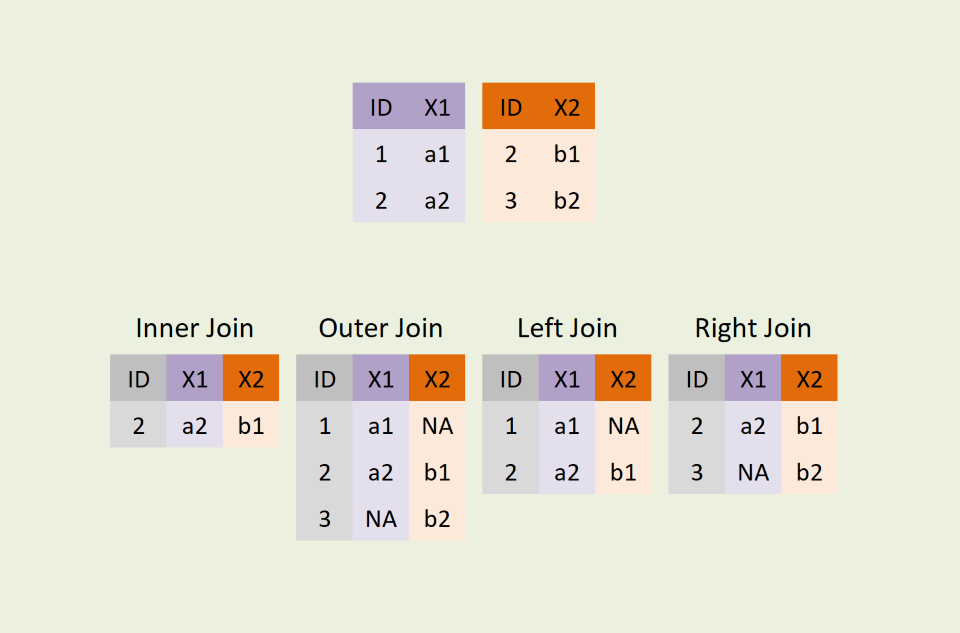

In [72]:
##The following images shows the different ways we can join data
join_png = Image.open('join_types.png')
display(join_png)

In [73]:
##Let's use merge to join our data
complete_data = pd.merge(wy_nri, wy_svi, on = 'STCNTY')
complete_data.head()

,Unnamed: 0,OID_,NRI_ID,STATE_x,STATEABBRV,STATEFIPS,COUNTY_x,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,0.0,1.2,0.0,1.2,0.0,1.2,6.1,5.2,0.0,1.2
1,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,0.3,0.5,0.5,0.6,0.0,1.2,7.4,4.0,0.7,1.1
2,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,1.7,2.3,1.0,1.2,0.0,2.2,3.6,2.3,0.0,2.2
3,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,0.6,1.1,0.4,0.6,0.0,1.5,4.5,3.8,0.0,1.5
4,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,6.5,5.6,0.0,1.0,0.0,1.0,1.4,1.4,0.0,1.0


In [74]:
complete_data_ok = pd.merge(ok_nri, ok_svi, on = 'STCNTY')
complete_data_ok.head()

,Unnamed: 0,OID_,NRI_ID,STATE_x,STATEABBRV,STATEFIPS,COUNTY_x,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,60081,60961,T40001376600,Oklahoma,OK,40,Adair,County,1,40001,...,0.0,1.0,27.9,6.5,0.2,0.3,7.2,3.5,0.0,1.0
1,60081,60961,T40001376600,Oklahoma,OK,40,Adair,County,1,40001,...,3.9,1.4,26.5,4.4,0.0,0.4,10.0,3.6,0.0,0.4
2,60081,60961,T40001376600,Oklahoma,OK,40,Adair,County,1,40001,...,0.1,0.2,56.8,4.1,0.0,0.5,10.8,2.9,0.0,0.5
3,60081,60961,T40001376600,Oklahoma,OK,40,Adair,County,1,40001,...,0.2,0.3,47.9,5.2,0.0,0.5,9.3,3.4,0.0,0.5
4,60081,60961,T40001376600,Oklahoma,OK,40,Adair,County,1,40001,...,1.4,1.6,52.5,4.7,0.0,0.5,8.8,3.0,0.0,0.5


In [75]:
complete_data.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE_x', 'STATEABBRV', 'STATEFIPS',
       'COUNTY_x', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=626)

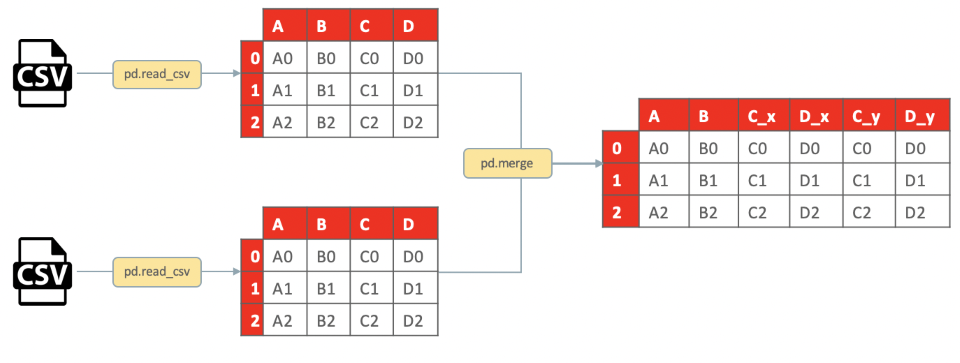

In [76]:
##This figure shows how pandas will merge two datasets if you don't supply any additional arguments to the merge function
merge_png2 = Image.open('flow_pandas_merge.png')
display(merge_png2)

Let's try to fix this `merge()` and remove extra rows.  We can use the `suffixes` argument of the `merge()` function.  The text below will remove the suffix the first time it sees a column like `STATE` and add `_right` the second time it sees `STATE`.

In [77]:
### Merge without repeat column names
complete_data = pd.merge(wy_nri, wy_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data.columns



Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS',
       'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=626)

In [78]:
complete_data_ok = pd.merge(ok_nri, ok_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data_ok.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS',
       'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=626)

Awesome, all set to go with our big dataset!

In [79]:
## Dr. Lane's Example
### Create a column called "my_risk" which multiplies your frequency by your impact
complete_data['my_risk'] = complete_data['HAIL_AFREQ']*complete_data['HAIL_EXPA']

##Use print to see if your code correctly multiples columns
print(complete_data['my_risk'], complete_data['HAIL_AFREQ'], complete_data['HAIL_EXPA'])


0       4.428784e+07
1       4.428784e+07
2       4.428784e+07
3       4.428784e+07
4       4.428784e+07
            ...     
1981    5.465138e+05
1982    1.938079e+08
1983    1.938079e+08
1984    6.369354e+06
1985    6.369354e+06
Name: my_risk, Length: 1986, dtype: float64 0       2.343512
1       2.343512
2       2.343512
3       2.343512
4       2.343512
          ...   
1981    0.422349
1982    4.501673
1983    4.501673
1984    5.937939
1985    5.937939
Name: HAIL_AFREQ, Length: 1986, dtype: float64 0       18898062.0
1       18898062.0
2       18898062.0
3       18898062.0
4       18898062.0
           ...    
1981     1293987.0
1982    43052413.0
1983    43052413.0
1984     1072654.0
1985     1072654.0
Name: HAIL_EXPA, Length: 1986, dtype: float64


In [80]:

complete_data['my_risk'] = complete_data['DRGT_AFREQ']*complete_data['DRGT_EXPA']

##Use print to see if your code correctly multiples columns
print(complete_data['my_risk'], complete_data['DRGT_AFREQ'], complete_data['DRGT_EXPA'])

0       0.000000e+00
1       0.000000e+00
2       0.000000e+00
3       0.000000e+00
4       0.000000e+00
            ...     
1981    4.769785e+07
1982    3.451207e+07
1983    3.451207e+07
1984    8.931917e+04
1985    8.931917e+04
Name: my_risk, Length: 1986, dtype: float64 0       16.627078
1       16.627078
2       16.627078
3       16.627078
4       16.627078
          ...    
1981    61.243072
1982    79.532858
1983    79.532858
1984    50.712589
1985    50.712589
Name: DRGT_AFREQ, Length: 1986, dtype: float64 0            0.000000
1            0.000000
2            0.000000
3            0.000000
4            0.000000
            ...      
1981    778828.557750
1982    433934.705014
1983    433934.705014
1984      1761.282056
1985      1761.282056
Name: DRGT_EXPA, Length: 1986, dtype: float64


In [81]:
##Example from Dr. Lane

### Create a column that multiplies Landslide annual frequency by building value loss
complete_data['landslide_building_risk'] = complete_data['LNDS_AFREQ']*complete_data['LNDS_EALB']

#print(complete_data)

In [82]:
### Student code that creates 3 new columns in the joined dataset
for df in [complete_data, complete_data_ok]:
    df['wildfire_risk']     = df['WFIR_AFREQ'] * df['WFIR_EALB']
    df['wind_risk']         = df['SWND_AFREQ'] * df['SWND_EALP']
    df['total_hazard_risk'] = df['wildfire_risk'] + df['wind_risk']

# Print the first few rows of your new columns to verify
print("New Risk Columns Created:")
display(complete_data[['COUNTY', 'wildfire_risk', 'wind_risk', 'total_hazard_risk']].head())

New Risk Columns Created:


,COUNTY,wildfire_risk,wind_risk,total_hazard_risk
0,Albany,223.789472,0.000735,223.790206
1,Albany,223.789472,0.000735,223.790206
2,Albany,223.789472,0.000735,223.790206
3,Albany,223.789472,0.000735,223.790206
4,Albany,223.789472,0.000735,223.790206


## Aggregate Data for Plotting and Reporting

Now the data we have created is great, but how do we present it to our client?  Well, what about all those filtering, grouping and aggregating skills we learned in Project #1?  Let's see if we can find a way to organize our data so it becomes plottable.

Let's first try grouping by county.  Now I have two columns, one for Hail damage to agriculture and Landslide damage to buildings.  That's probably not the best comparison, but it is a comparison so let's use it as an example.  Our end goal is: a grouped bar plot by county.

In [83]:
### Group your data by county
grouped_data = complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data = complete_data.groupby('COUNTY').agg(mean_hail=('my_risk', 'mean'), 
                                                   mean_lnds=('landslide_building_risk', 'mean'))

print(grouped_data)

                mean_hail     mean_lnds
COUNTY                                 
Albany       0.000000e+00    375.477108
Big Horn     1.152937e+09   1340.390105
Campbell     1.738267e+07    722.116359
Carbon       5.308749e+07   2179.248930
Converse     1.240933e+08   1332.565861
Crook        9.424966e+07    135.212027
Fremont      2.073036e+08    656.185273
Goshen       8.611070e+08      6.842035
Hot Springs  2.977455e+07   5722.694032
Johnson      7.511974e+07  10612.565702
Laramie      5.030584e+07     12.234692
Lincoln      8.113083e+07   7157.765012
Natrona      1.945693e+07    288.555947
Niobrara     2.791161e+08    204.371522
Park         5.217180e+08   8714.343607
Platte       3.492282e+08     70.400148
Sheridan     7.762078e+07   2244.258624
Sublette     9.887788e+07    746.539741
Sweetwater   2.139026e+07   1525.633957
Teton        1.704221e+07  53819.935842
Uinta        2.998449e+07    238.991950
Washakie     3.708090e+08   3652.053547
Weston       1.730069e+07    273.830561


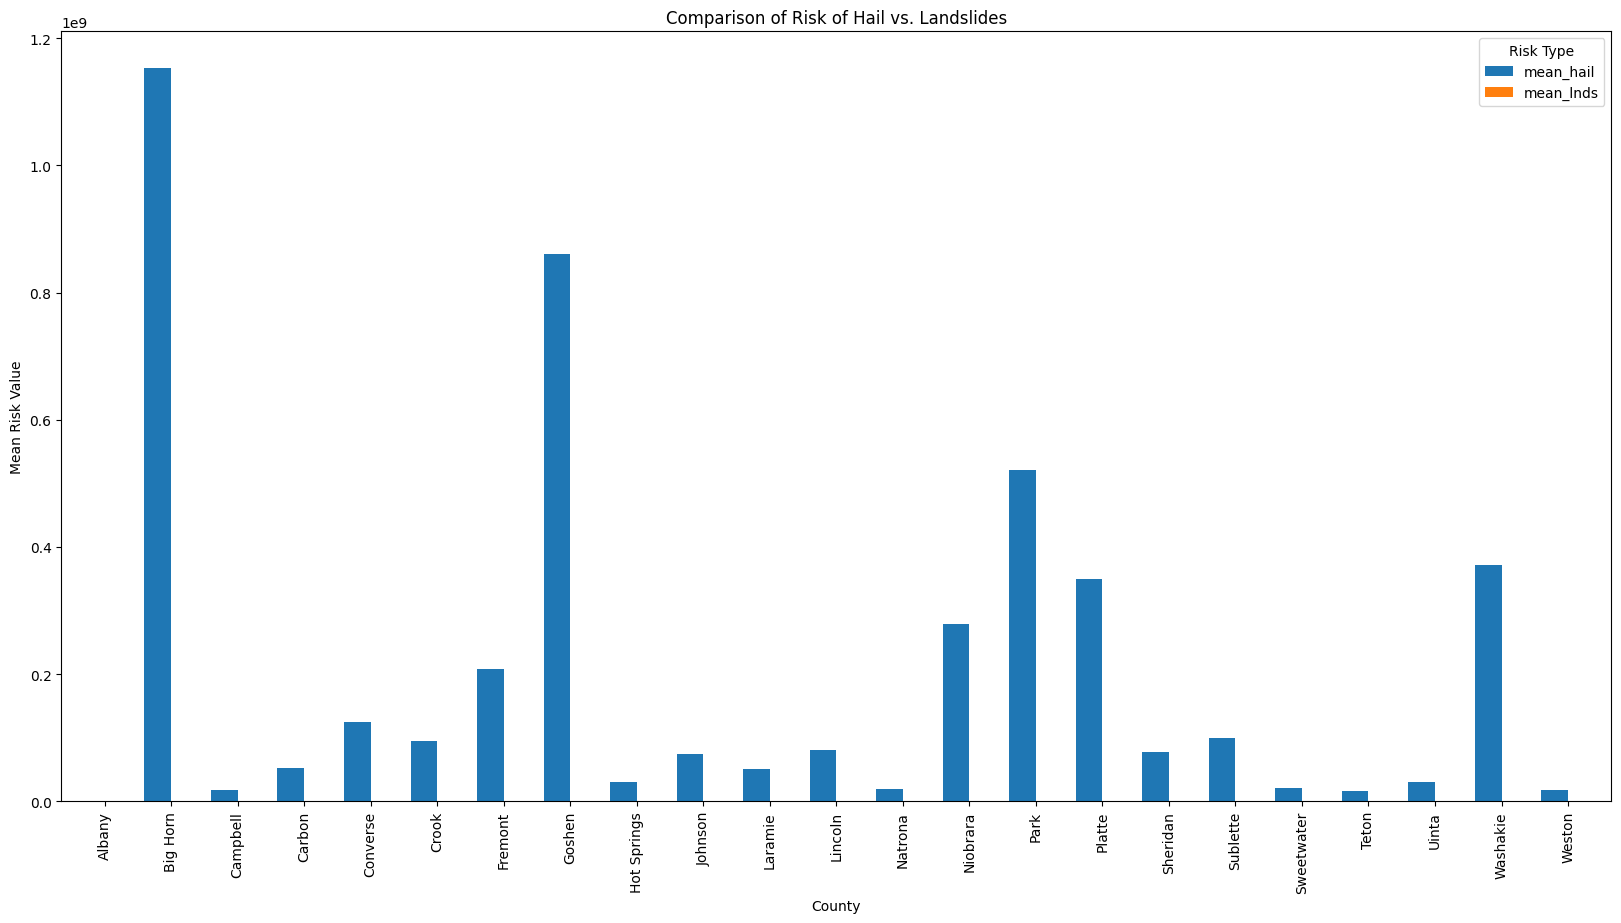

In [84]:
# Create bar plot with side-by-side bars (dodged effect)
grouped_data.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Comparison of Risk of Hail vs. Landslides')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()

## Section 1 — Handle Missing / NA Values 

In [85]:
for label, df in [("Wyoming", complete_data), ("Oklahoma", complete_data_ok)]:
    print(f"=== {label} — Missing Value Summary ===")
    print(f"  Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"  Columns with NaN: {len(missing)}")
    if len(missing):
        print(missing.head(10).to_string())
    print()

=== Wyoming — Missing Value Summary ===
  Shape: 1986 rows x 631 columns
  Columns with NaN: 102
AVLN_EVNTS       1566
AVLN_AFREQ       1566
AVLN_EXP_AREA    1566
AVLN_EXPB        1566
AVLN_EXPP        1566
AVLN_EXPPE       1566
AVLN_EXPT        1566
AVLN_HLRB        1566
AVLN_HLRP        1566
AVLN_EALB        1566

=== Oklahoma — Missing Value Summary ===
  Shape: 129341 rows x 629 columns
  Columns with NaN: 102
AVLN_EVNTS       129341
AVLN_AFREQ       129341
AVLN_EXP_AREA    129341
AVLN_EXPB        129341
AVLN_EXPP        129341
AVLN_EXPPE       129341
AVLN_EXPT        129341
AVLN_HLRB        129341
AVLN_HLRP        129341
AVLN_EALB        129341



In [86]:
def clean_nri_data(df, label=""):
    df = df.copy()

    # Replace NRI sentinel value -999 with NaN
    df.replace(-999, np.nan, inplace=True)

    # Numeric columns: fill NaN with 0
    # Rationale: missing frequency/loss = no documented hazard events
    num_cols = df.select_dtypes(include=[np.number]).columns
    na_before = df[num_cols].isnull().sum().sum()
    df[num_cols] = df[num_cols].fillna(0)
    print(f"[{label}] Numeric NaN filled: {na_before} -> 0")

    # String columns: fill NaN with 'Unknown'
    str_cols = df.select_dtypes(include=['object']).columns
    df[str_cols] = df[str_cols].fillna('Unknown')

    return df

complete_data    = clean_nri_data(complete_data,    "Wyoming")
complete_data_ok = clean_nri_data(complete_data_ok, "Oklahoma")

print("\nRemaining NaN after cleaning:")
print("  Wyoming: ",  complete_data.isnull().sum().sum())
print("  Oklahoma:", complete_data_ok.isnull().sum().sum())

[Wyoming] Numeric NaN filled: 190564 -> 0
[Oklahoma] Numeric NaN filled: 10372037 -> 0

Remaining NaN after cleaning:
  Wyoming:  0
  Oklahoma: 0


## Section 2 — New Risk Index

### Formula
$$\text{Risk} = \frac{\text{Hazard Exposure}}{\text{Community Resilience Score} + 0.01}$$

**Hazard Exposure** = sum of (Annual Frequency × Expected Annual Loss) across 6 key hazards:  
Wildfire, Severe Wind, Drought, Tornado, Winter Storm, Hail.

**Community Resilience Score** = average of 4 min-max normalized sub-scores:
1. Social connectedness — SVI `RPL_THEME2` (inverted: higher vulnerability = lower resilience)
2. Economic stability — SVI `RPL_THEME1` (inverted)
3. NRI Community Resilience — `RESL_SCORE` (direct)
4. NRI Social Vulnerability — `SOVI_SCORE` (inverted)

The +0.01 constant prevents division by zero.  
The final score is normalized to **0–100** for direct comparison with NRI percentiles.

In [87]:
HAZARD_PAIRS = {
    'wildfire':     ('WFIR_AFREQ', 'WFIR_EALB'),   # buildings
    'severe_wind':  ('SWND_AFREQ', 'SWND_EALB'),
    'drought':      ('DRGT_AFREQ', 'DRGT_EALA'),   # agriculture
    'tornado':      ('TRND_AFREQ', 'TRND_EALB'),
    'winter_storm': ('WNTW_AFREQ', 'WNTW_EALB'),
    'hail':         ('HAIL_AFREQ', 'HAIL_EALA'),   # agriculture
}

def compute_hazard_exposure(df, label=""):
    df = df.copy()
    exposure = pd.Series(0.0, index=df.index)
    for hazard, (freq_col, loss_col) in HAZARD_PAIRS.items():
        if freq_col in df.columns and loss_col in df.columns:
            component = df[freq_col] * df[loss_col]
            df[f'exposure_{hazard}'] = component
            exposure += component
        else:
            print(f"  [{label}] Skipping {hazard}: column(s) not found")
    df['hazard_exposure'] = exposure
    print(f"[{label}] hazard_exposure — min: {exposure.min():.2f}, max: {exposure.max():.2f}, mean: {exposure.mean():.2f}")
    return df

complete_data    = compute_hazard_exposure(complete_data,    "Wyoming")
complete_data_ok = compute_hazard_exposure(complete_data_ok, "Oklahoma")

[Wyoming] hazard_exposure — min: 2735.83, max: 13474722.91, mean: 189734.48
[Oklahoma] hazard_exposure — min: 1876.12, max: 989138927.44, mean: 473614.21


In [88]:
def min_max_normalize(series):
    """Scale a series to [0, 1]. Returns 0.5 everywhere if range is zero."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

def compute_resilience(df, label=""):
    df = df.copy()
    scores = {}

    # 1. Social connectedness — SVI Theme 2 (higher percentile = more vulnerable, so invert)
    if 'RPL_THEME2' in df.columns:
        scores['social_connectedness'] = 1 - min_max_normalize(df['RPL_THEME2'])
    elif 'EPL_MINRTY' in df.columns:
        scores['social_connectedness'] = 1 - min_max_normalize(df['EPL_MINRTY'])
        print(f"  [{label}] Used EPL_MINRTY as proxy for social connectedness")

    # 2. Economic stability — SVI Theme 1 (higher = more vulnerable, so invert)
    if 'RPL_THEME1' in df.columns:
        scores['economic_stability'] = 1 - min_max_normalize(df['RPL_THEME1'])
    elif 'EPL_POV150' in df.columns:
        scores['economic_stability'] = 1 - min_max_normalize(df['EPL_POV150'])
        print(f"  [{label}] Used EPL_POV150 as proxy for economic stability")

    # 3. NRI Community Resilience (higher = more resilient, use directly)
    if 'RESL_SCORE' in df.columns:
        scores['nri_resilience'] = min_max_normalize(df['RESL_SCORE'])

    # 4. NRI Social Vulnerability (higher = more vulnerable, so invert)
    if 'SOVI_SCORE' in df.columns:
        scores['sovi_inverted'] = 1 - min_max_normalize(df['SOVI_SCORE'])

    if not scores:
        raise ValueError(f"[{label}] No resilience columns found. Check df.columns.")

    df['resilience_score'] = pd.DataFrame(scores, index=df.index).mean(axis=1)
    print(f"[{label}] Sub-scores used: {list(scores.keys())}")
    print(f"[{label}] resilience_score range: {df['resilience_score'].min():.3f} - {df['resilience_score'].max():.3f}")
    return df

complete_data    = compute_resilience(complete_data,    "Wyoming")
complete_data_ok = compute_resilience(complete_data_ok, "Oklahoma")

[Wyoming] Sub-scores used: ['social_connectedness', 'economic_stability', 'nri_resilience', 'sovi_inverted']
[Wyoming] resilience_score range: 0.070 - 0.900
[Oklahoma] Sub-scores used: ['social_connectedness', 'economic_stability', 'nri_resilience', 'sovi_inverted']
[Oklahoma] resilience_score range: 0.056 - 0.928


In [89]:
def compute_new_risk(df, label=""):
    df = df.copy()

    # Core formula
    df['new_risk_raw'] = df['hazard_exposure'] / (df['resilience_score'] + 0.01)

    # Normalize to 0-100 for comparison with NRI percentile scores
    df['new_risk_score'] = min_max_normalize(df['new_risk_raw']) * 100

    # Rank tracts: 1 = most at risk
    df['new_risk_rank'] = df['new_risk_score'].rank(ascending=False, method='min').astype(int)

    # Qualitative ratings matching NRI's 5-tier system
    bins   = [0, 20, 40, 60, 80, 100]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    df['new_risk_rating'] = pd.cut(df['new_risk_score'], bins=bins, labels=labels, include_lowest=True)

    print(f"\n[{label}] New Risk Score summary:")
    print(df['new_risk_score'].describe().round(2))
    print(f"\n[{label}] New Risk Rating distribution:")
    print(df['new_risk_rating'].value_counts().sort_index())
    return df

complete_data    = compute_new_risk(complete_data,    "Wyoming")
complete_data_ok = compute_new_risk(complete_data_ok, "Oklahoma")


[Wyoming] New Risk Score summary:
count    1986.00
mean        1.10
std         4.23
min         0.00
25%         0.11
50%         0.20
75%         0.57
max       100.00
Name: new_risk_score, dtype: float64

[Wyoming] New Risk Rating distribution:
new_risk_rating
Very Low     1975
Low             7
Medium          1
High            2
Very High       1
Name: count, dtype: int64

[Oklahoma] New Risk Score summary:
count    129341.00
mean          0.03
std           0.66
min           0.00
25%           0.00
50%           0.00
75%           0.01
max         100.00
Name: new_risk_score, dtype: float64

[Oklahoma] New Risk Rating distribution:
new_risk_rating
Very Low     129313
Low              21
Medium            3
High              2
Very High         2
Name: count, dtype: int64


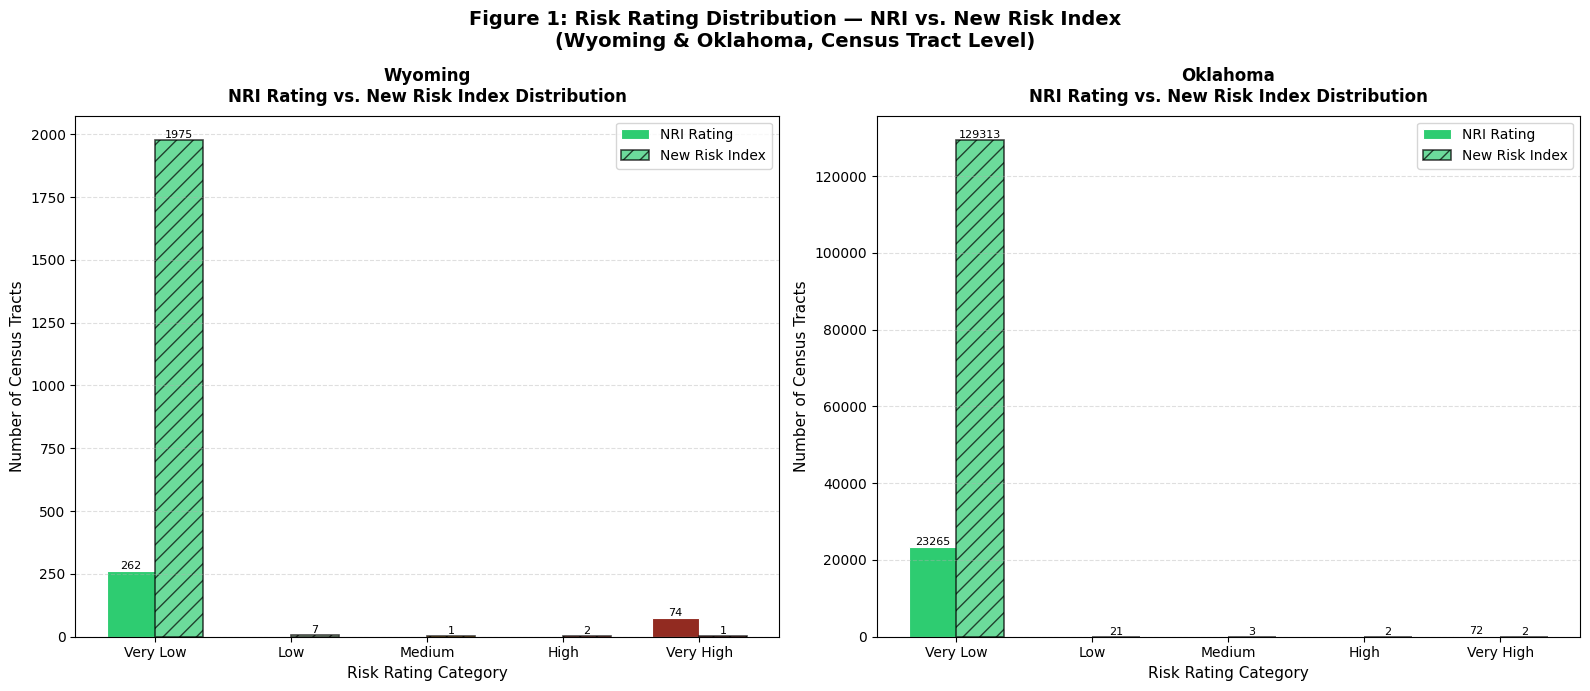

Figure 1 saved.


In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rating_order  = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
rating_colors = ['#2ecc71', '#a8d8a8', '#f39c12', '#e74c3c', '#922b21']

for ax, (df, state) in zip(axes, [(complete_data, "Wyoming"), (complete_data_ok, "Oklahoma")]):

    nri_counts = df['RISK_RATNG'].value_counts().reindex(rating_order, fill_value=0)
    new_counts = df['new_risk_rating'].astype(str).value_counts().reindex(rating_order, fill_value=0)

    x     = np.arange(len(rating_order))
    width = 0.35

    bars1 = ax.bar(x - width/2, nri_counts.values, width,
                   label='NRI Rating', color=rating_colors, edgecolor='white', linewidth=0.8)
    bars2 = ax.bar(x + width/2, new_counts.values, width,
                   label='New Risk Index', color=rating_colors,
                   edgecolor='black', linewidth=1.2, alpha=0.7, hatch='//')

    ax.set_title(f"{state}\nNRI Rating vs. New Risk Index Distribution",
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Risk Rating Category', fontsize=11)
    ax.set_ylabel('Number of Census Tracts', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(rating_order, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.3,
                    str(int(h)), ha='center', va='bottom', fontsize=8)

plt.suptitle("Figure 1: Risk Rating Distribution — NRI vs. New Risk Index\n(Wyoming & Oklahoma, Census Tract Level)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figure1_rating_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

## Section 3 — Summary Figures

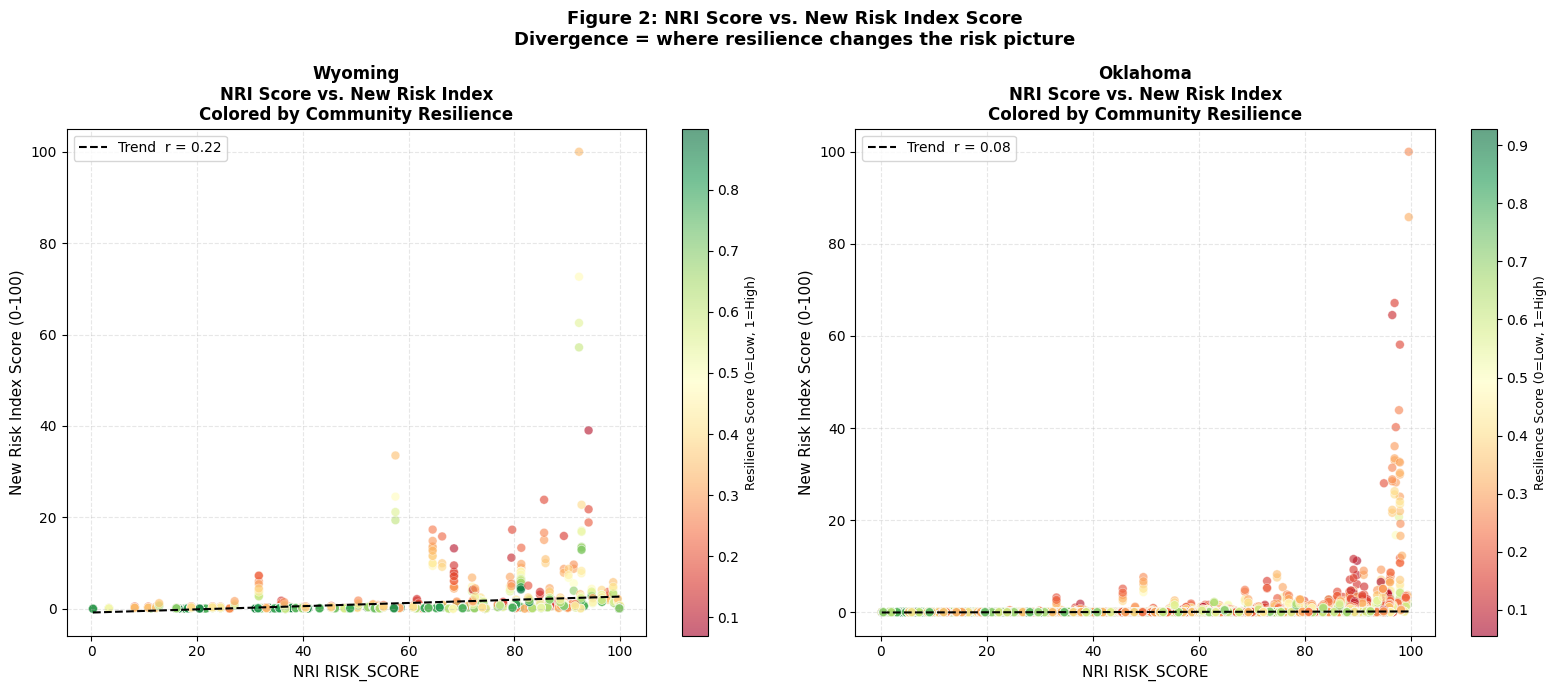

Figure 2 saved.


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (df, state) in zip(axes, [(complete_data, "Wyoming"), (complete_data_ok, "Oklahoma")]):

    nri_col = 'RISK_SCORE' if 'RISK_SCORE' in df.columns else 'RESL_SCORE'
    x_vals  = df[nri_col].fillna(0)
    y_vals  = df['new_risk_score'].fillna(0)

    sc = ax.scatter(x_vals, y_vals,
                    c=df['resilience_score'],
                    cmap='RdYlGn',
                    alpha=0.6,
                    edgecolors='white',
                    linewidths=0.4,
                    s=40)

    corr = np.corrcoef(x_vals, y_vals)[0, 1]
    m, b = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, label=f'Trend  r = {corr:.2f}')

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Resilience Score (0=Low, 1=High)', fontsize=9)

    ax.set_xlabel(f'NRI {nri_col}', fontsize=11)
    ax.set_ylabel('New Risk Index Score (0-100)', fontsize=11)
    ax.set_title(f"{state}\nNRI Score vs. New Risk Index\nColored by Community Resilience",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(linestyle='--', alpha=0.3)

plt.suptitle("Figure 2: NRI Score vs. New Risk Index Score\nDivergence = where resilience changes the risk picture",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("figure2_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

In [92]:
def build_summary_table(df, state):
    nri_col = 'RISK_SCORE' if 'RISK_SCORE' in df.columns else None

    agg = {
        'new_risk_score':   ['mean', 'max'],
        'hazard_exposure':  'mean',
        'resilience_score': 'mean',
        'new_risk_rating':  lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown',
    }
    if nri_col:
        agg[nri_col] = 'mean'

    summary = df.groupby('COUNTY').agg(agg).round(2)
    col_names = ['Mean New Risk', 'Max New Risk', 'Mean Hazard Exposure',
                 'Mean Resilience', 'Most Common New Rating']
    if nri_col:
        col_names.append('Mean NRI Score')
    summary.columns = col_names
    summary = summary.sort_values('Mean New Risk', ascending=False)

    print(f"\n=== {state}: County-Level Summary (top 10 by New Risk) ===")
    display(summary.head(10))
    return summary

summary_wy = build_summary_table(complete_data,    "Wyoming")
summary_ok = build_summary_table(complete_data_ok, "Oklahoma")


=== Wyoming: County-Level Summary (top 10 by New Risk) ===


,Mean New Risk,Max New Risk,Mean Hazard Exposure,Mean Resilience,Most Common New Rating,Mean NRI Score
COUNTY,,,,,,
Goshen,26.91,100.00,4956349.63,0.48,Very Low,75.22
Big Horn,18.60,39.04,1496741.70,0.23,Very Low,86.99
Niobrara,17.30,17.30,1268999.37,0.18,Very Low,79.58
Platte,9.90,15.93,1000680.33,0.27,Very Low,78.38
Crook,9.22,10.84,1448704.23,0.40,Very Low,89.29
Weston,3.69,5.07,473566.44,0.35,Very Low,77.59
Park,2.93,22.76,666386.72,0.61,Very Low,78.51
Converse,2.86,9.67,373678.06,0.35,Very Low,74.88
Washakie,2.64,8.72,451701.00,0.44,Very Low,77.53



=== Oklahoma: County-Level Summary (top 10 by New Risk) ===


,Mean New Risk,Max New Risk,Mean Hazard Exposure,Mean Resilience,Most Common New Rating,Mean NRI Score
COUNTY,,,,,,
Cimarron,47.00,100.00,5.005287e+08,0.30,Very Low,73.78
Harmon,28.01,28.01,1.880358e+08,0.18,Low,94.91
Harper,20.70,25.10,2.300516e+08,0.30,Very Low,97.96
Beaver,20.29,43.88,2.381718e+08,0.37,Very Low,80.39
Texas,17.34,67.15,1.727059e+08,0.32,Very Low,75.71
Roger Mills,12.27,12.27,1.420433e+08,0.32,Very Low,98.31
Greer,8.22,9.00,9.646597e+07,0.32,Very Low,82.92
Ellis,5.47,8.55,6.813092e+07,0.38,Very Low,86.00
Jefferson,3.65,6.77,2.662609e+07,0.21,Very Low,73.38


## Section 4 — GeoPandas Choropleth Map

In [93]:
import os, zipfile

def load_shapefile(zip_path, label):
    """Unzip and load a Census Tract shapefile into a GeoDataFrame."""
    extract_dir = zip_path.replace('.zip', '')
    if not os.path.exists(extract_dir):
        print(f"Extracting {zip_path} ...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_dir)
    shp_files = [f for f in os.listdir(extract_dir) if f.endswith('.shp')]
    if not shp_files:
        raise FileNotFoundError(f"No .shp file found in {extract_dir}")
    gdf = gpd.read_file(os.path.join(extract_dir, shp_files[0]))
    print(f"[{label}] Loaded: {gdf.shape[0]} tracts | CRS: {gdf.crs}")
    return gdf

gdf_wy = load_shapefile('tl_2022_56_tract.zip', 'Wyoming')
gdf_ok = load_shapefile('tl_2022_40_tract.zip', 'Oklahoma')

[Wyoming] Loaded: 160 tracts | CRS: EPSG:4269
[Oklahoma] Loaded: 1205 tracts | CRS: EPSG:4269


In [94]:
def join_geo_risk(gdf, risk_df, label):
    gdf      = gdf.copy()
    risk_df  = risk_df.copy()

    # Shapefile GEOID = 11-digit Census tract FIPS
    gdf['GEOID'] = gdf['GEOID'].astype(str).str.zfill(11)

    # Find matching FIPS column in risk_df
    fips_col = next((c for c in ['TRACTFIPS', 'FIPS', 'GEOID'] if c in risk_df.columns), None)
    if fips_col is None:
        raise KeyError(f"[{label}] No FIPS column found. First 20 cols: {list(risk_df.columns[:20])}")

    risk_df['GEOID'] = risk_df[fips_col].astype(str).str.zfill(11)

    keep = [c for c in ['GEOID', 'COUNTY', 'new_risk_score', 'new_risk_rating',
                         'resilience_score', 'hazard_exposure', 'RISK_SCORE']
            if c in risk_df.columns]

    merged  = gdf.merge(risk_df[keep].drop_duplicates('GEOID'), on='GEOID', how='left')
    matched = merged['new_risk_score'].notna().sum()
    print(f"[{label}] Tracts matched: {matched} / {len(merged)}")
    return merged

geo_wy = join_geo_risk(gdf_wy, complete_data,    "Wyoming")
geo_ok = join_geo_risk(gdf_ok, complete_data_ok, "Oklahoma")

[Wyoming] Tracts matched: 160 / 160
[Oklahoma] Tracts matched: 1205 / 1205


[Wyoming] Top 3 highest-risk counties (mean score):
COUNTY
Goshen      21.0
Niobrara    17.3
Platte      14.3
[Oklahoma] Top 3 highest-risk counties (mean score):
COUNTY
Cimarron    43.4
Harmon      28.0
Harper      22.2


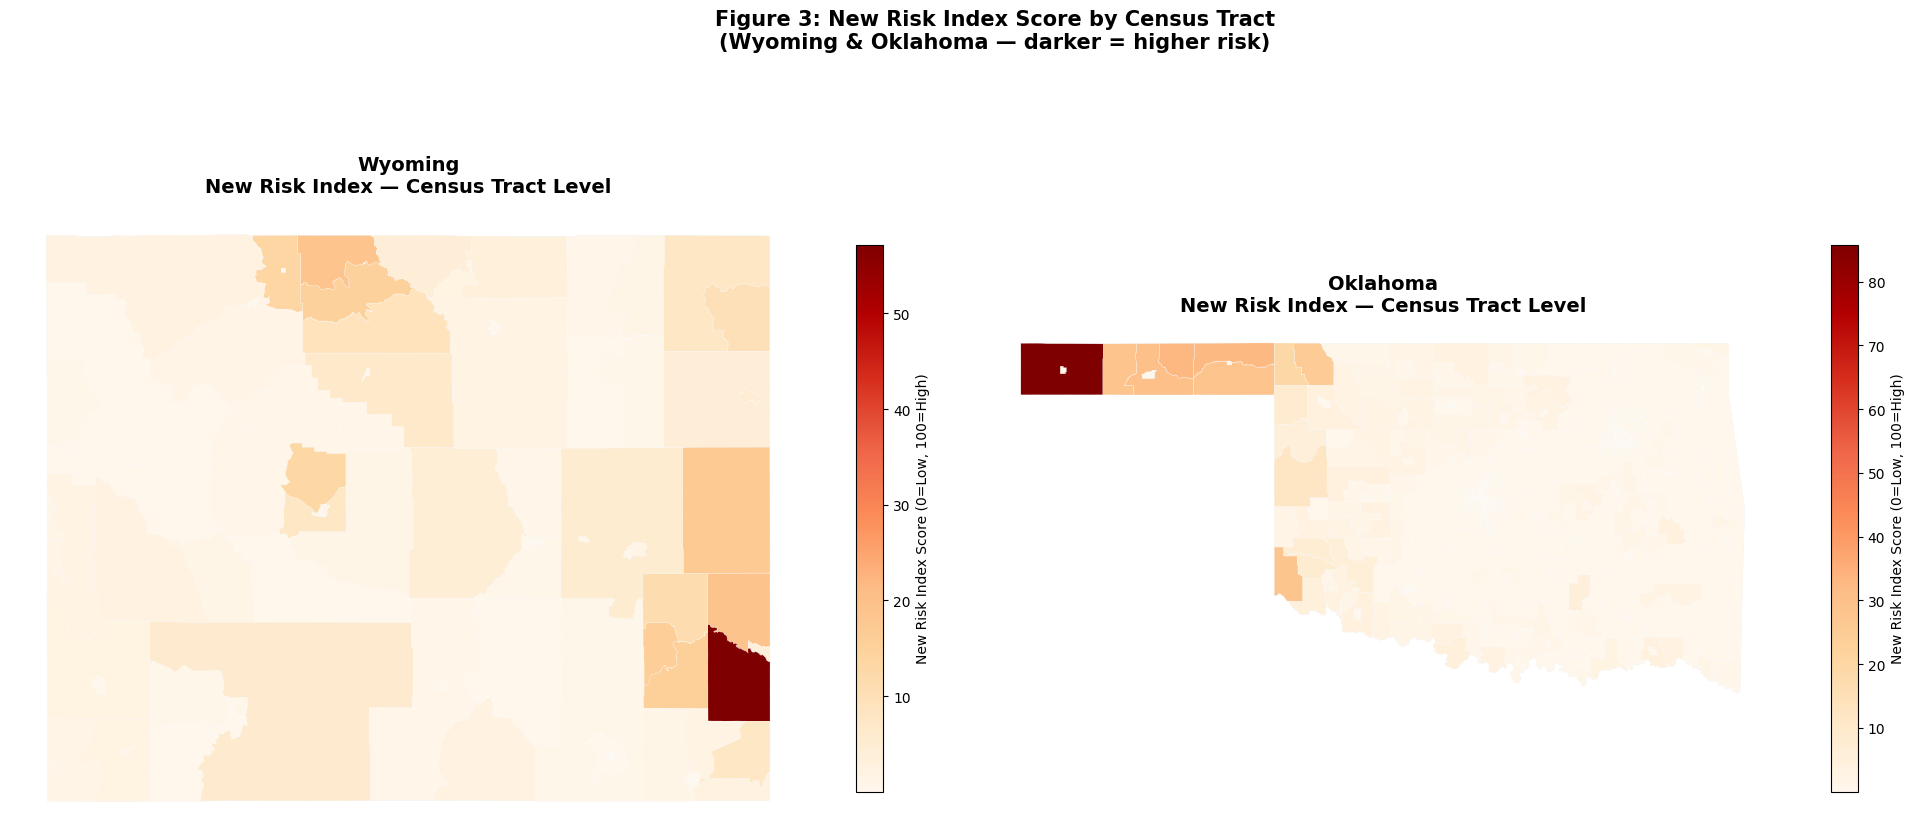

Map saved as figure3_risk_map.png


In [95]:
# ── Figure 3: GeoPandas Choropleth Map ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, (gdf_plot, state) in zip(axes, [(geo_wy, "Wyoming"), (geo_ok, "Oklahoma")]):

    # Gray base for unmatched tracts
    gdf_plot.plot(ax=ax, color='#d3d3d3', edgecolor='white', linewidth=0.2)

    # Choropleth on matched tracts — New Risk Index Score
    gdf_matched = gdf_plot.dropna(subset=['new_risk_score'])
    gdf_matched.plot(
        ax=ax,
        column='new_risk_score',
        cmap='OrRd',
        edgecolor='white',
        linewidth=0.2,
        legend=True,
        legend_kwds={
            'label': 'New Risk Index Score (0=Low, 100=High)',
            'orientation': 'vertical',
            'shrink': 0.6,
        }
    )

    ax.set_title(f"{state}\nNew Risk Index — Census Tract Level",
                 fontsize=14, fontweight='bold', pad=10)
    ax.set_axis_off()

    if 'COUNTY' in gdf_matched.columns:
        top = gdf_matched.groupby('COUNTY')['new_risk_score'].mean().nlargest(3)
        print(f"[{state}] Top 3 highest-risk counties (mean score):")
        print(top.round(1).to_string())

plt.suptitle("Figure 3: New Risk Index Score by Census Tract\n(Wyoming & Oklahoma — darker = higher risk)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("figure3_risk_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Map saved as figure3_risk_map.png")

## Section 5 — Categorical Bias Analysis


In [96]:
def bias_analysis(df, state):
    df = df.copy()
    high_cats = ['High', 'Very High']
    low_cats  = ['Very Low', 'Low']

    nri_high = df['RISK_RATNG'].isin(high_cats)
    nri_low  = df['RISK_RATNG'].isin(low_cats)
    new_high = df['new_risk_rating'].astype(str).isin(high_cats)
    new_low  = df['new_risk_rating'].astype(str).isin(low_cats)

    both_agree    = ((nri_high & new_high) | (nri_low & new_low)).sum()
    nri_hi_new_lo = (nri_high & new_low).sum()
    nri_lo_new_hi = (nri_low  & new_high).sum()
    total         = len(df)

    print(f"\n=== {state}: Categorical Bias Report ===")
    print(f"  Total census tracts:                    {total}")
    print(f"  Both methods agree (High or Low):       {both_agree}  ({both_agree/total*100:.1f}%)")
    print(f"  NRI High / New Index Low:               {nri_hi_new_lo}  ({nri_hi_new_lo/total*100:.1f}%)")
    print(f"    -> NRI may OVERRATE risk (ignores strong community resilience)")
    print(f"  NRI Low  / New Index High:              {nri_lo_new_hi}  ({nri_lo_new_hi/total*100:.1f}%)")
    print(f"    -> NRI may UNDERRATE risk (ignores low community resilience)")

    result = pd.DataFrame({
        'Category': [
            'Both agree (both High or both Low)',
            'NRI High / New Index Low — NRI may overrate risk',
            'NRI Low / New Index High — NRI may underrate risk',
        ],
        'Tracts': [both_agree, nri_hi_new_lo, nri_lo_new_hi],
        'Percent': [f"{both_agree/total*100:.1f}%",
                    f"{nri_hi_new_lo/total*100:.1f}%",
                    f"{nri_lo_new_hi/total*100:.1f}%"]
    })
    display(result)
    return result

bias_wy = bias_analysis(complete_data,    "Wyoming")
bias_ok = bias_analysis(complete_data_ok, "Oklahoma")


=== Wyoming: Categorical Bias Report ===
  Total census tracts:                    1986
  Both methods agree (High or Low):       262  (13.2%)
  NRI High / New Index Low:               74  (3.7%)
    -> NRI may OVERRATE risk (ignores strong community resilience)
  NRI Low  / New Index High:              0  (0.0%)
    -> NRI may UNDERRATE risk (ignores low community resilience)


,Category,Tracts,Percent
0,Both agree (both High or both Low),262,13.2%
1,NRI High / New Index Low — NRI may overrate risk,74,3.7%
2,NRI Low / New Index High — NRI may underrate risk,0,0.0%



=== Oklahoma: Categorical Bias Report ===
  Total census tracts:                    129341
  Both methods agree (High or Low):       23267  (18.0%)
  NRI High / New Index Low:               68  (0.1%)
    -> NRI may OVERRATE risk (ignores strong community resilience)
  NRI Low  / New Index High:              0  (0.0%)
    -> NRI may UNDERRATE risk (ignores low community resilience)


,Category,Tracts,Percent
0,Both agree (both High or both Low),23267,18.0%
1,NRI High / New Index Low — NRI may overrate risk,68,0.1%
2,NRI Low / New Index High — NRI may underrate risk,0,0.0%
